# Глубокое обучение 


## Тема 5. Нормализующие потоки. Модель RealNVP 🌀 

Ранее мы рассмотрели три семейства генеративных моделей: __вариационные автокодировщики__ (VAE), __генеративно-состязательные сети__ (GAN) и __авторегрессионные модели__ (ARM). Каждое из этих семейств представляет собой свой способ решения проблемы моделирования распределения $p\left(x\right)$: либо путем введения скрытой переменной, для которой можно легко формировать случайные выборки (и преобразовывать их с помощью декодера в VAE или генератора в GAN), либо путем моделирования распределения как функции значений предыдущих элементов (авторегрессионные модели).

Рассмотрим новое семейство генеративных моделей — __нормализующие потоки__ (normalizing flows, NFL). Нормализующие потоки имеют сходство как с авторегрессионными моделями, так и с вариационными автокодировщиками. Как и авторегрессионные модели, нормализующие потоки способны явно и понятно моделировать распределение $p\left(x\right)$, генерирующее данные. Как и VAE, нормализующие потоки пытаются сопоставить данные с более простым распределением, например, распределением Гаусса. Ключевое отличие состоит в том, что нормализующие потоки накладывают ограничение на функцию отображения – она является обратимой и, следовательно, может использоваться для генерации новых точек данных.

### Нормализующие потоки 

Идея нормализующих потоков аналогична идее вариационных автокодировщиков. В вариационном автокодировщике мы изучаем функцию отображения кодировщика между сложным распределением и гораздо более простым распределением, из которого мы можем делать выборку. Затем мы также изучаем функцию отображения декодера из более простого распределения в сложное распределение, чтобы мы могли сгенерировать новую точку данных, выбрав точку $z$ из более простого распределения и применив изученное отображение. С вероятностной точки зрения, декодер моделирует распределение $p\left(x\mid z\right)$, а кодировщик представляет собой лишь аппроксимацию $q\left(z\mid x\right)$ истинного распределения $p\left(z\mid x\right)$, при этом кодировщик и декодер представляют собой две совершенно разные нейронные сети.

В нормализующих потоках функция декодирования устроена так, чтобы быть в точности равной обратной функциии к функции кодирования и быстро вычисляться, что придает нормализующим потокам свойство управляемости. Однако нейронные сети по умолчанию не являются обратимыми функциями. Это поднимает вопрос о том, как можно создать обратимый процесс, который преобразует сложное распределение (например, распределение для генерации данных набора изображений) в гораздо более простое распределение (например, распределение Гаусса), продолжая использовать гибкость и мощь глубокого обучения.

Нормализующие потоки базируются на математической технике, известной как __замена переменных__. Рассмотрим простой пример в двух измерениях, чтобы увидеть, как именно работают нормализующие потоки. 

### Пример замены переменных

Предположим, у нас есть распределение вероятностей с плотностью $p_{X}\left(x\right)=\frac{1}{9}\left(x_{1}-1\right)x_{2}$, определенное над прямоугольником $X=\left[1,\,4\right]\times\left[0,\,2\right]$ в двух измерениях ($x=\left(x_{1},x_{2}\right)$).

Интеграл от плотности распределения по области распределения (т. е. по $x_{1}$ в диапазоне $[1,4]$ и $x_{2}$ в диапазоне $[0,2]$) должен быть равен единице:

$$\intop_{0}^{2}\intop_{1}^{4}p_{X}\left(x_{1},x_{2}\right)dx_{1}dx_{2}=1$$
$$\intop_{0}^{2}\intop_{1}^{4}p_{X}\left(x_{1},x_{2}\right)dx_{1}dx_{2}=\frac{1}{9}\intop_{1}^{4}\left(x_{1}-1\right)dx_{1}\intop_{0}^{2}x_{2}dx_{2}=\frac{1}{9}\left(\frac{x_{1}^{2}}{2}-x_{1}\right)\left|_{1}^{4}\right.\frac{x_{2}^{2}}{2}\left|_{0}^{2}\right.=\frac{1}{9}\left(\frac{16}{2}-4-\frac{1}{2}+1\right)\frac{4}{2}=1$$

Допустим, мы хотим сдвинуть и масштабировать это распределение так, чтобы вместо этого оно было определено на единичном квадрате $Z=\left[0,\,1\right]\times\left[0,\,1\right]$. Мы можем добиться этого, определив новую переменную $z=\left(z_1,\,z_2\right)$ и функцию $f$, которая отображает каждую точку $X$ ровно в одну точку в $Z$ следующим образом:

$$z=\left(z_{1},z_{2}\right)=f\left(x_{1},x_{2}\right)=\left(\frac{x_{1}-1}{3},\frac{x_{2}}{2}\right)$$

Обратите внимание, что функция $f$ обратима, то есть существует функция $g$, которая отображает каждую точку $z$ обратно в соответствующую ей точку $x$. Это важно для замены переменных, поскольку в противном случае мы не сможем последовательно выполнять отображения в прямом и обратном направлениях между двумя пространствами $X$ и $Z$. Мы можем найти функцию $g$, просто разрешив уравнения, определяющие функцию $f$.

<!--img src="10_NFL_01.pdf" width=600-->

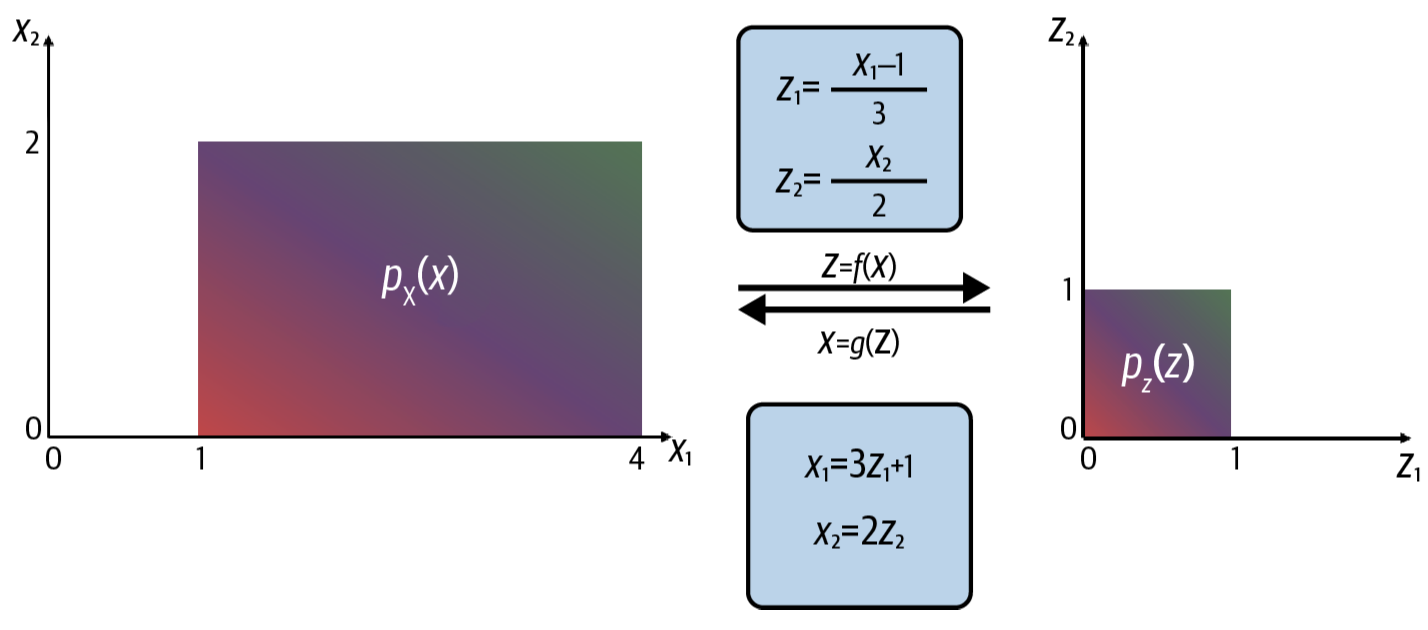

Теперь нам нужно посмотреть, как замена переменных $X$ на $Z$ влияет на распределение вероятностей $p_{X}\left(x\right)$. Мы можем сделать это, подставив уравнения, определяющие функцию $g$, в функцию $p_{X}\left(x\right)$, чтобы преобразовать ее в функцию $p_{Z}\left(z\right)$, которая определяется через $z$:

$$p_{Z}\left(z\right)=\frac{2}{9}\left(\left(3\,z_{1}+1\right)-1\right)z_{2}=\frac{2}{3}z_{1}z_{2}$$

Однако, если теперь проинтегрировать $p_{Z}\left(z\right)$ по единичному квадрату, то получим

$$\intop_{0}^{1}\intop_{0}^{1}p_{Z}\left(z_{1},z_{2}\right)dz_{1}dz_{2}=\intop_{0}^{1}\intop_{0}^{1}\frac{2}{3}z_{1}z_{2}dz_{1}dz_{2}=\frac{1}{6}$$

Преобразованная функция $p_{Z}\left(z\right)$ больше не задает корректное распределение вероятностей, поскольку интеграл равен $\frac{1}{6}$. Если мы хотим преобразовать наше сложное распределение вероятностей для данных в более простое распределение, из которого мы можем делать выборку, то мы должны гарантировать, что интеграл от плотности распределения будет равен 1. Недостающий коэффициент 6 связан с тем, что область нашего преобразованного распределения вероятностей в шесть раз меньше исходной области — исходный прямоугольник $X$ имел площадь 6, и она была сжата в единичный квадрат $Z$, который имеет только площадь 1. Поэтому нам нужно умножить функцию для нового распределения вероятностей на коэффициент нормализации, равный относительному изменению площади (или объема в более высоких измерениях). К счастью, есть способ вычислить это изменение объема для данного преобразования — это абсолютное значение определителя матрицы Якоби (якобиана) преобразования. 

### Определитель якобиана

Якобиева матрица функции $z=f\left(x\right)$ – это $m\times n$-матрица частных производных первого порядка:

$$J=\frac{\partial z}{\partial x}=\left[\begin{array}{ccc}
\frac{\partial z_{1}}{\partial x_{1}} & \ldots & \frac{\partial z_{1}}{\partial x_{n}}\\
\vdots & \ddots & \vdots\\
\frac{\partial z_{m}}{\partial x_{1}} & \ldots & \frac{\partial z_{m}}{\partial x_{n}}
\end{array}\right]$$

Якобиева матрица в рассматривавшемся примере равна

$$J=\left[\begin{array}{cc}
\frac{1}{3} & 0\\
0 & \frac{1}{2}
\end{array}\right]$$

Определитель матрицы Якоби (якобиан) определен только для квадратных матриц и равен объему со знаком параллелепипеда, созданного путем применения преобразования, представленного матрицей, к единичному (гипер)кубу. Таким образом, в двух измерениях это просто площадь параллелограмма (со знаком), созданного путем применения преобразования, представленного матрицей, к единичному квадрату.

Для вычисления определителя квадратной матрицы размерами $n\times n$ существует общая формула, в случае двух измерений вычисления формула выглядит так:

$$\det\left[\begin{array}{cc}
a & b\\
c & d
\end{array}\right]=\left|\begin{array}{cc}
a & b\\
c & d
\end{array}\right|=a\,d-b\,c$$

Поэтому в нашем примере якобиан равен $\frac{1}{3}\times\frac{1}{2}-0\times0=\frac{1}{6}$. Это масштабирующий коэффициент $\frac{1}{6}$, который нам нужен, чтобы гарантировать, что интеграл от плотности распределения вероятностей после преобразования по-прежнему равен 1. По определению определитель имеет знак, то есть может быть отрицательным. Поэтому нам нужно взять абсолютное значение якобиана, чтобы получить относительное изменение объема.

### Уравнение плотности при замене переменных

Теперь мы можем записать соотношение, которое описывает процесс изменения переменных между $X$ и $Z$ ($z=f\left(x\right)$). Это соотношение известно как уравнение замены переменных в плотности вероятности:

$$p_{X}\left(x\right)=p_{Z}\left(z\right)\left|\det\left[\frac{\partial z}{\partial x}\right]\right|$$

Более строгая формулировка выглядит так. Если $\xi$ – случайная величина с областью значений $X\subset\mathbb{R}$ и функция $f$ определена на множестве $X$, то $\eta=\varphi\left(\xi\right)$ – также случайная величина. Если $\varphi$ – монотонно возрастающая функция класса $C^{1}\left(\mathbb{R}\right)$, то плотность распределения случайной величины $\eta$ вычисляется по формуле

$$p_{\eta}\left(x\right)=p_{\xi}\left(\varphi^{-1}\left(x\right)\right)\,\frac{d}{dx}\left(\varphi^{-1}\left(x\right)\right),$$

где $p_{\xi}\left(x\right)$ – плотность распределения случайной величины $\xi$, $\varphi^{-1}$ – функция, обратная к функции $\varphi$. Для многомерного случая формула для плотности принимает вид:

$$p_{\eta}\left(x\right)=p_{\xi}\left(\varphi^{-1}\left(x\right)\right)\,\left|\det\left[\frac{\partial\varphi^{-1}\left(x\right)}{\partial x}\right]\right|$$

Как эта формула поможет нам построить генеративную модель? Ключевым моментом является понимание того, что если $p_{Z}\left(z\right)$ — это простое распределение, из которого мы можем легко выполнить выборку (например, гауссово распределение), то теоретически все, что нам нужно сделать, – это найти подходящую обратимую функцию $f\left(x\right)$, которая может отображать данные $X$ в $Z$, и соответствующую обратную функцию $g\left(z\right)$, которую можно использовать для отображения случайно выбранной точки $z\in Z$ обратно в точку $x$ в исходной области $X$. Мы можем использовать предыдущее уравнение, включающее якобиан, чтобы найти точную и понятную формулу для распределения данных $p\left(x\right)$. 

Однако при применении этого подхода на практике есть две основные проблемы, которые нам в первую очередь необходимо решить.

Во-первых, вычисление определителя многомерной матрицы чрезвычайно затратно в вычислительном отношении — в частности, это затраты порядка $O\left(n^{3}\right)$. Это совершенно непрактично реализовать на практике, поскольку даже небольшие полутоновые изображения размером $32×32$ пикселя имеют $1024$ измерения.

Во-вторых, не совсем очевидно, как нам следует действовать при вычислении обратимой функции $f\left(x\right)$. Мы могли бы использовать нейронную сеть, чтобы найти некоторую функцию $f\left(x\right)$, но мы не можем гарантированно инвертировать эту функцию — нейронные сети работают только в одном направлении.

Чтобы решить эти две проблемы, нам необходимо использовать специальную архитектуру нейронной сети, которая гарантирует, что функция замены переменных $f$ обратима и имеет определитель, который легко вычислить. В следующем разделе мы увидим, как это сделать, используя технику, называемую преобразованием __RealNVP__ (real-valued non-volume preserving) или вещественнозначным преобразованием без сохранения объема.

### Подход RealNVP

Подход RealNVP был впервые представлен в 2017 году (Dinh, L., Sohl-Dickstein, J., and Bengio, S. (2017). “Density estimation using Real NVP,” In: 5th International Conference on Learning Representations, ICLR 2017. [Link](https://arxiv.org/abs/1605.08803)). При помощи RealNVP можно построить нейронную сеть, которая может преобразовать сложное распределение данных в простое гауссово, обладая при этом желаемыми свойствами обратимости и наличия якобиана, который можно легко вычислить.

In [1]:
from silence_tensorflow import silence_tensorflow
silence_tensorflow()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
tf.__version__

'2.15.1'

In [3]:
tf.config.set_visible_devices([], 'GPU') # блокируем GPU/MPS

Здесь используем виртуальное окружение с библиотекой `tensorflow_probability` версии 0.23.0
```bash
!pip install --upgrade tensorflow==2.15.1 numpy scipy pandas matplotlib scikit-learn tensorflow_probability==0.23.0 ipykernel ipywidgets plotnine silence_tensorflow statsmodels tqdm
```

In [4]:
from sklearn import datasets

from tensorflow.keras import (
    layers,
    models,
    regularizers,
    metrics,
    optimizers,
    callbacks,
)

import tensorflow_probability as tfp # version 0.23.0

## Параметры

In [5]:
COUPLING_DIM = 256
COUPLING_LAYERS = 6
INPUT_DIM = 2
REGULARIZATION = 0.01
BATCH_SIZE = 256
EPOCHS = 100

### Набор данных Two Moons

Набор данных, который мы будем использовать в этом примере, создан функцией `make_moons` из библиотеки sklearn. Эта функция создает зашумленный набор данных из точек в 2D, напоминающих два полумесяца.

Построим модель RealNVP, которая сможет генерировать точки в 2D, которые соответствуют распределению, похожему на набор данных двух полумесяцев. Этот пример поможет нам понять, как модель нормализующих потоков работает на практике. 

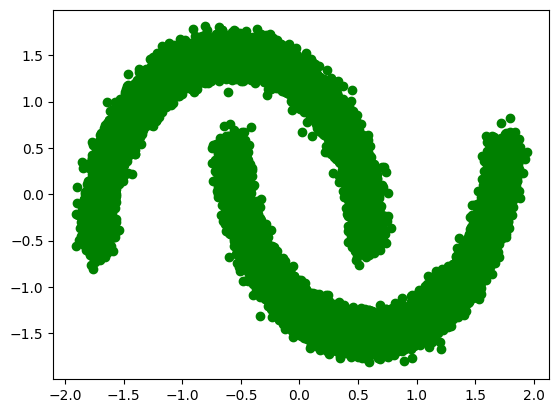

In [6]:
# Load the data
data = datasets.make_moons(30000, noise=0.05)[0].astype("float32")
norm = layers.Normalization()
norm.adapt(data)
normalized_data = norm(data)
plt.scatter(
    normalized_data.numpy()[:, 0], normalized_data.numpy()[:, 1], c="green"
)
plt.show()

## Построение сети RealNVP

### Соединительные слои 

__Соединительный слой__ (coupling layer) создает коэффициенты масштабирования и трансляции для каждого элемента входных данных. Другими словами, он создает два тензора точно такого же размера, что и входные данные: один для масштабирующего коэффициента (scaling factor $s$), другой для коэффициента трансляции (translation factor $t$) или сдвига, как показано на рисунке.

<!--img src="10_NFL_02.pdf" width=400-->

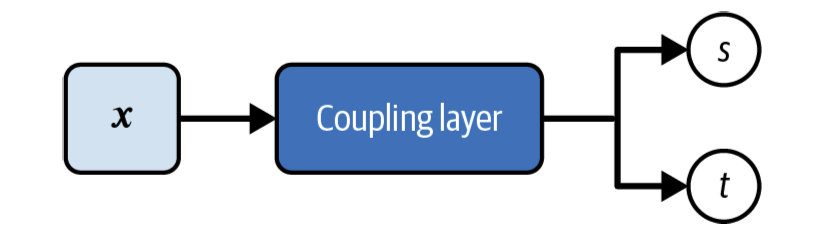

Чтобы создать собственный соединительный слой для нашего простого примера, мы можем объединить слои `Dense` для создания выходных данных масштабирования и другой набор слоев `Dense` для создания выходных данных трансляции. Для изображений блоки соединительного слоя используют слои `Conv2D` вместо слоев `Dense`.

Входные данные блока соединительных слоев (coupling layer) в нашем примере имеют два измерения. Поток масштабирования (scaling) представляет собой стек слоев `Dense` размером 256. Последний масштабирующий слой имеет размер 2 и имеет активацию `tanh`. Поток трансляции (translation) представляет собой стек слоев `Dense` размером 256. Последний слой трансляции имеет размер 2 и имеет линейную активацию. Cоединительный слой построен как функциональная модель Keras с двумя выходными данными (коэффициентами масштабирования и трансляции).

Обратите внимание, как количество каналов временно увеличивается (с `input_dim` до `coupling_dim`), чтобы можно было изучить более сложное представление, прежде чем снова свернуть его до того же количества каналов `input_dim`, что и входные данные. Также  используются  регуляризаторы $L_2$ в каждом слое для штрафования больших весов.

In [7]:
def Coupling(input_dim, coupling_dim, reg):
    input_layer = layers.Input(shape=input_dim)

    s_layer_1 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(input_layer)
    s_layer_2 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(s_layer_1)
    s_layer_3 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(s_layer_2)
    s_layer_4 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(s_layer_3)
    s_layer_5 = layers.Dense(
        input_dim, activation="tanh", 
        kernel_regularizer=regularizers.l2(reg)
    )(s_layer_4)

    t_layer_1 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(input_layer)
    t_layer_2 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(t_layer_1)
    t_layer_3 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(t_layer_2)
    t_layer_4 = layers.Dense(
        coupling_dim, activation="relu", 
        kernel_regularizer=regularizers.l2(reg)
    )(t_layer_3)
    t_layer_5 = layers.Dense(
        input_dim, activation="linear", 
        kernel_regularizer=regularizers.l2(reg)
    )(t_layer_4)

    return models.Model(inputs=input_layer, 
                        outputs=[s_layer_5, t_layer_5])

### Передача данных через соединительный слой 

Архитектура соединительного слоя не представляет особого интереса — его уникальность заключается в том, как именно входные данные $x$ маскируются и преобразуются после прохождения через соединительный слой, как показано на рисунке ниже.

<!--img src="10_NFL_03.pdf" width=400-->

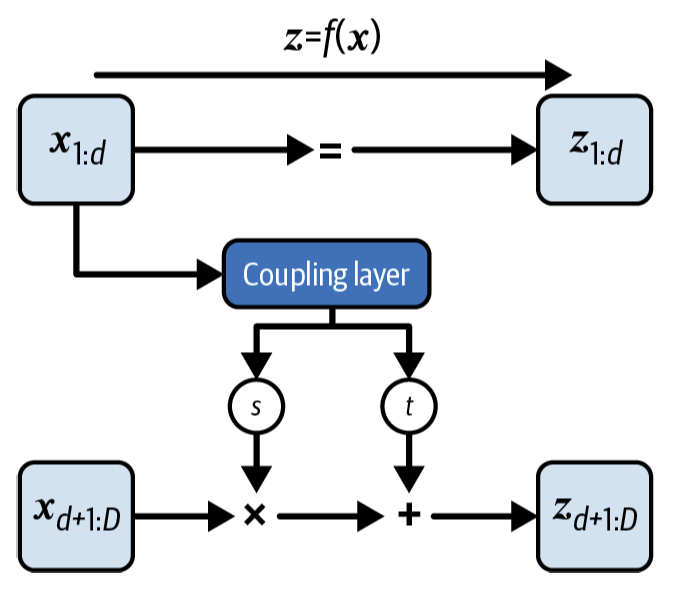

Обратите внимание, что на первый соединительный слой передаются только первые $d$ измерений данных, а остальные измерения $D-d$ полностью маскируются (т. е. устанавливаются в ноль). В нашем простом примере с $D=2$ выбор $d=1$ означает, что вместо двух значений $x_{1},x_{2}$ соединительный слой видит $x_{1},0$.

Выходными данными слоя являются коэффициенты масштабирования $s$ и трансляции $t$. Они снова маскируются, но на этот раз с маской, обратной предыдущей, так что пропускаются только вторые половины — т. е. в нашем примере мы получаем $0,s_{2}$ и $0,t_{2}$. Затем они поэлементно применяются ко второй половине входных данных $x_{2}$, а первая половина входных данных $x_{1}$ просто передается напрямую, вообще не обновляясь. Таким образом, для вектора с размерностью $D$, где $d<D$, уравнения обновления выглядят следующим образом:

$$z_{1:d}=x_{1:d},\,z_{d+1:D}=x_{d+1:D}\odot\exp\left(s\left(x_{1:d}\right)\right)+t\left(x_{1:d}\right)$$

Не очень понятно, зачем создается такой слой, который маскирует так много информации. Ответ становится ясен, если исследовать структуру матрицы Якоби этой функции:

$$\frac{\partial z}{\partial x}=\left[\begin{array}{cc}
\mathbf{I} & 0\\
\frac{\partial z_{d+1:D}}{\partial x_{1:d}} & \mathrm{diag}\left(\exp\left(s\left(x_{1:d}\right)\right)\right)
\end{array}\right]$$

Верхняя левая подматрица размером $d\times d$ — это просто единичная матрица, поскольку $z_{1:d}=x_{1:d}$. Эти элементы передаются напрямую без обновления. Тогда верхняя правая подматрица размерами $d\times\left(D-d\right)$  равна $0$, поскольку $z_{1:d}$ не зависит от $x_{d+1:D}$.

Левая нижняя подматрица $\frac{\partial z_{d+1:D}}{\partial x_{1:d}}$ размерами $\left(D-d\right)\times d$ сложна, но это не играет роли. Нижняя правая подматрица размерами $\left(D-d\right)\times\left(D-d\right)$ представляет собой просто диагональную матрицу, заполненную элементами $\exp\left(s\left(x_{1:d}\right)\right)$, поскольку $z_{d+1:D}$ линейно зависит от $x_{d+1:D}$, а градиент зависит только от масштабирующего коэффициента (а не от коэффициента трансляции). На рисунке ниже показана визуализация этой матрицы, где только ненулевые элементы заполнены цветом.

<!--img src="10_NFL_04.pdf" width=600-->

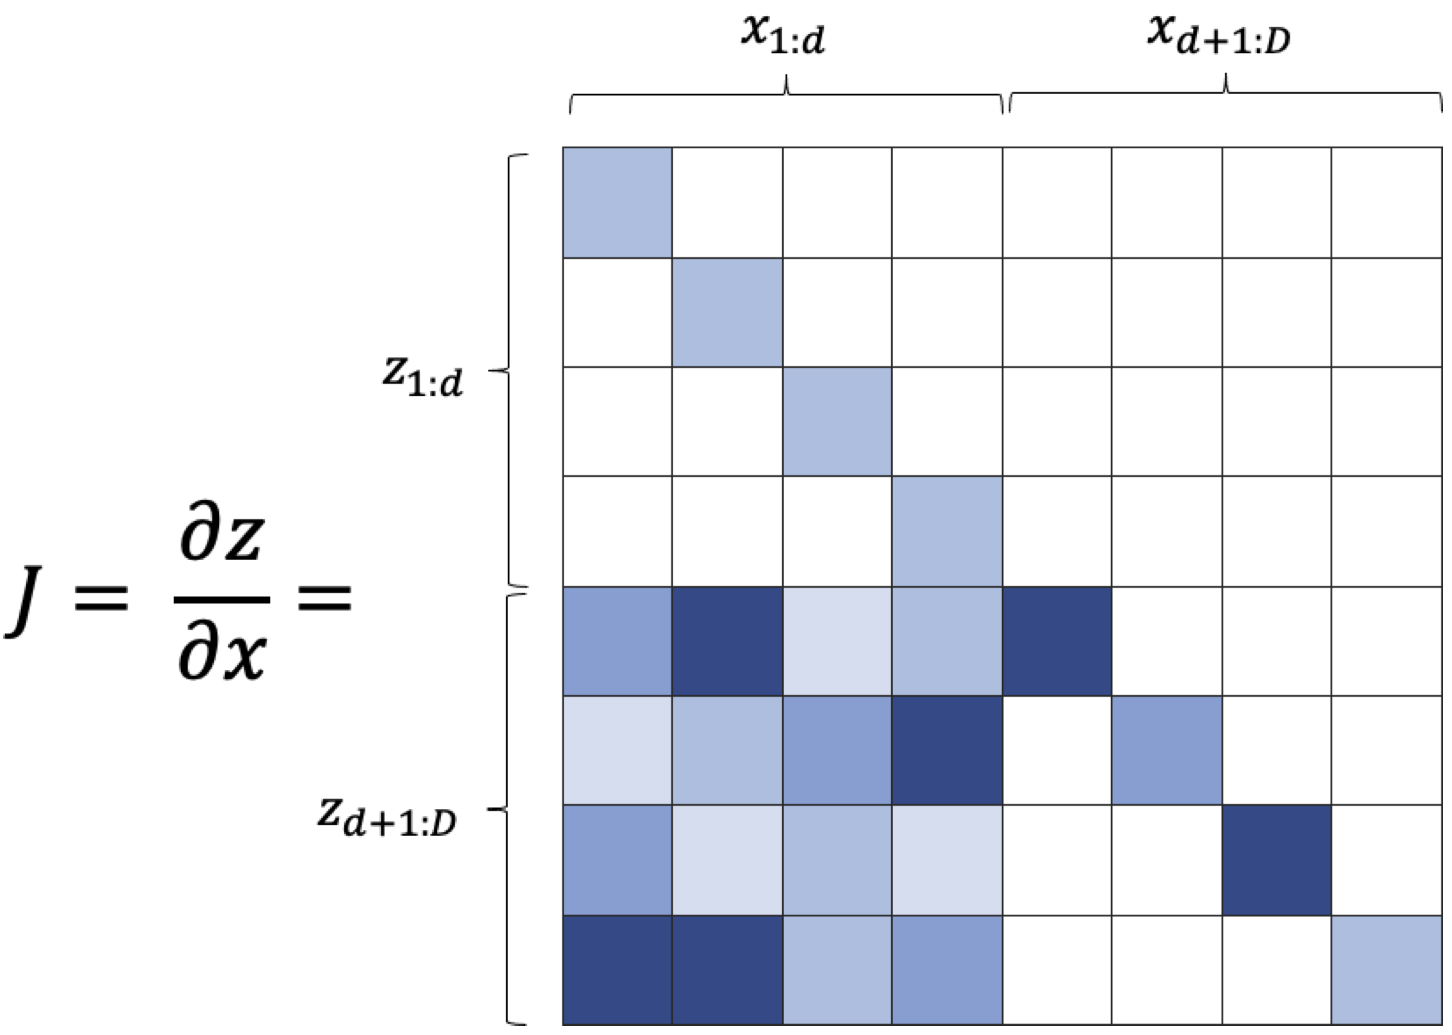

Обратите внимание, что выше главной диагонали нет ненулевых элементов — по этой причине такая матрица называется нижнетреугольной. Теперь мы видим преимущество такой матрицы: определитель нижнетреугольной матрицы просто равен произведению диагональных элементов. Другими словами, определитель не зависит ни от одной из сложных производных в нижней левой подматрице, которые сложно вычислить.

Поэтому определитель этой матрицы можно записать следующим образом:

$$\det\left(J\right)=\exp\left(\sum_{j}s\left(x_{1:d}\right)_{j}\right).$$

Это выражение легко вычислить, что было одной из двух первоначальных целей построения модели нормализующих потоков. 

Другая цель заключалась в том, чтобы функция была легко обратимой. Мы видим, что это верно, поскольку мы можем записать обратимую функцию, просто переставив прямые уравнения следующим образом:

$$x_{1:d}=z_{1:d},\,x_{d+1:D}=\left(z_{d+1:D}-t\left(x_{1:d}\right)\right)\odot\exp\left(-s\left(x_{1:d}\right)\right).$$

Эквивалентная диаграмма показана на рисунке ниже.

<!--img src="10_NFL_05.pdf" width=400-->

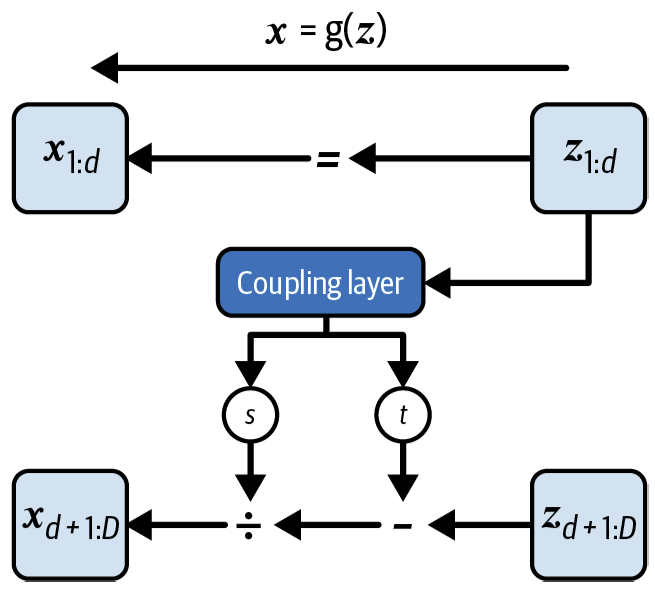

Теперь у нас есть почти все необходимое для построения модели RealNVP. Однако остается одна проблема: как нам обновить первые $d$ элементов входных данных? На данный момент они оставлены моделью полностью неизмененными.

### Стекирование соединительных слоев 

Чтобы решить эту проблему, можно использовать очень простой трюк. Если мы наложим соединительные слои друг на друга, но будем чередовать шаблон маскировки, то слои, которые остались необновленными, по одному будут обновлены в дальнейшем. Эта архитектура имеет дополнительное преимущество, заключающееся в возможности изучения более сложных представлений данных, поскольку она представляет собой более глубокую нейронную сеть. 

Якобиан этой композиции соединительных слоев по-прежнему будет легко вычислить, поскольку линейная алгебра говорит нам, что определитель матричного произведения является произведением определителей. Точно так же обратная функция к композиции двух функций — это просто композиция обратных, как показано в следующих уравнениях:

$$\det\left(A\cdot B\right)=\det\left(A\right)\det\left(B\right),\,\left(f_{b}\circ f_{a}\right)^{-1}=f_{a}^{-1}\circ f_{b}^{-1}$$

Следовательно, если мы сложим соединительные слои, каждый раз переворачивая маску, то мы сможем построить нейронную сеть, которая способна преобразовать весь входной тензор, сохраняя при этом основные свойства наличия простого якобиана и обратимости функции. На рисунке ниже показана общая структура.

<!--img src="10_NFL_06.pdf" width=600-->

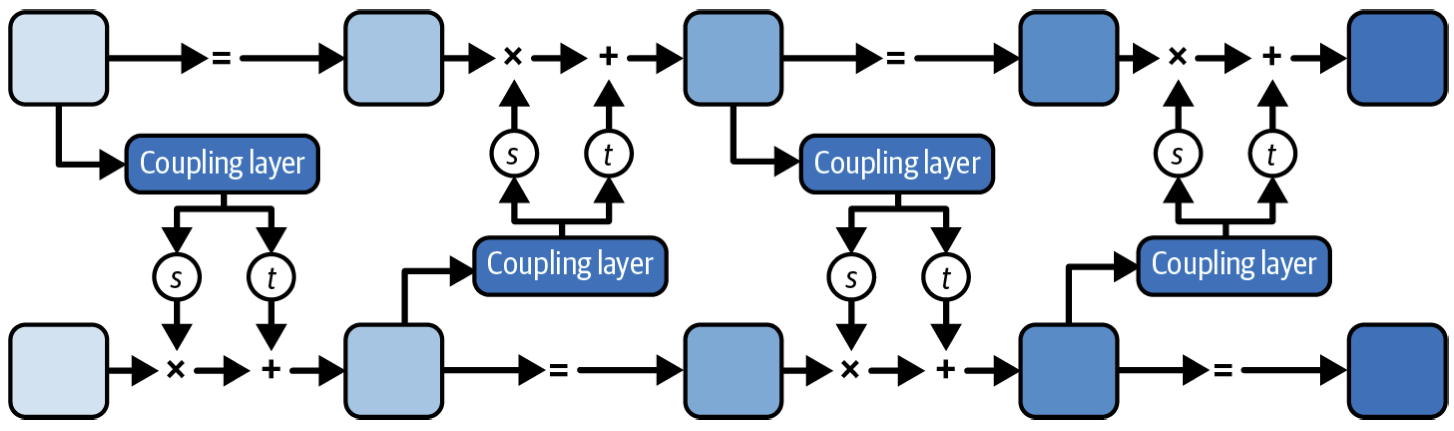

In [8]:
class RealNVP(models.Model):
    def __init__(
        self, input_dim, coupling_layers, coupling_dim, regularization
    ):
        super(RealNVP, self).__init__()
        self.coupling_layers = coupling_layers
        self.distribution = tfp.distributions.MultivariateNormalDiag(
            loc=[0.0, 0.0], scale_diag=[1.0, 1.0]
        ) # 1) стандартное двумерное гауссово распределение
        self.masks = np.array(
            [[0, 1], [1, 0]] * (coupling_layers // 2), dtype="float32"
        ) # 2) чередующийся шаблон маски
        self.loss_tracker = metrics.Mean(name="loss")
        self.layers_list = [
            Coupling(input_dim, coupling_dim, regularization)
            for i in range(coupling_layers)
        ] # 3) список соединительных слоев

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x, training=True): 
        log_det_inv = 0
        direction = 1
        if training:
            direction = -1
        for i in range(self.coupling_layers)[::direction]: # 4) направление движения по слоям
            x_masked = x * self.masks[i]
            reversed_mask = 1 - self.masks[i]
            s, t = self.layers_list[i](x_masked)
            s *= reversed_mask
            t *= reversed_mask
            gate = (direction - 1) / 2
            x = (
                reversed_mask
                * (x * tf.exp(direction * s) 
                   + direction * t * tf.exp(gate * s))
                + x_masked
            ) # 5) прямое и обратное уравнения
            log_det_inv += gate * tf.reduce_sum(s, axis=1) # 6) логарифм якобиана
        return x, log_det_inv

    def log_loss(self, x):
        y, logdet = self(x)
        log_likelihood = self.distribution.log_prob(y) + logdet # 7) минус логарифм вероятности
        return -tf.reduce_mean(log_likelihood)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self.log_loss(data)
        g = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(g,self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self.log_loss(data)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


model = RealNVP(
    input_dim=INPUT_DIM,
    coupling_layers=COUPLING_LAYERS,
    coupling_dim=COUPLING_DIM,
    regularization=REGULARIZATION,
)

1. Целевое распределение представляет собой стандартное двумерное гауссово распределение. 

2. Здесь мы создаем чередующийся шаблон маски. 

3. Список соединительных слоев, определяющих сеть RealNVP. 

4. В основной функции вызова сети мы перебираем соединительные слои. Если `training=True`, то мы движемся вперед по слоям (т. е. от данных к скрытому пространству). Если `training=False`, мы движемся назад по слоям (т. е. от скрытого пространства к данным). 

5. Эта строка описывает как прямое, так и обратное уравнение в зависимости от направления (попробуйте подставить `direction=-1` и `direction=1`, чтобы убедиться в этом). 

6. Логарифмический якобиан, который нам нужен для расчета функции потерь, представляет собой просто сумму коэффициентов масштабирования. 

7. Функция потерь представляет собой отрицательную сумму логарифмической вероятности преобразованных данных при нашем целевом гауссовском распределении и логарифмическом якобиане.

## Обучение сети RealNVP 

Теперь, когда мы построили модель RealNVP, мы можем обучить ее изучению сложного распределения набора данных двух полумесяцев. Мы хотим минимизировать отрицательное логарифмическое правдоподобие данных в рамках модели $-\log p_{X}\left(x\right)$. Используя формулу плотности вероятности при замене переменных, мы можем записать это следующим образом:

$$\text{–}\log p_{X}\left(x\right)=\text{–}\log p_{Z}\left(z\right)-\log\left|\det\left[\frac{\partial z}{\partial x}\right]\right|$$

Мы выберем целевое выходное распределение $p_{Z}\left(z\right)$ прямого процесса $f$ как стандартное гауссово, потому что мы можем легко делать выборку из этого распределения. Затем мы можем преобразовать точку, выбранную из гауссового распределения, обратно в исходную область определения, применив обратный процесс $g$, как показано на рисунке ниже.

<!--img src="10_NFL_07.pdf" width=600-->

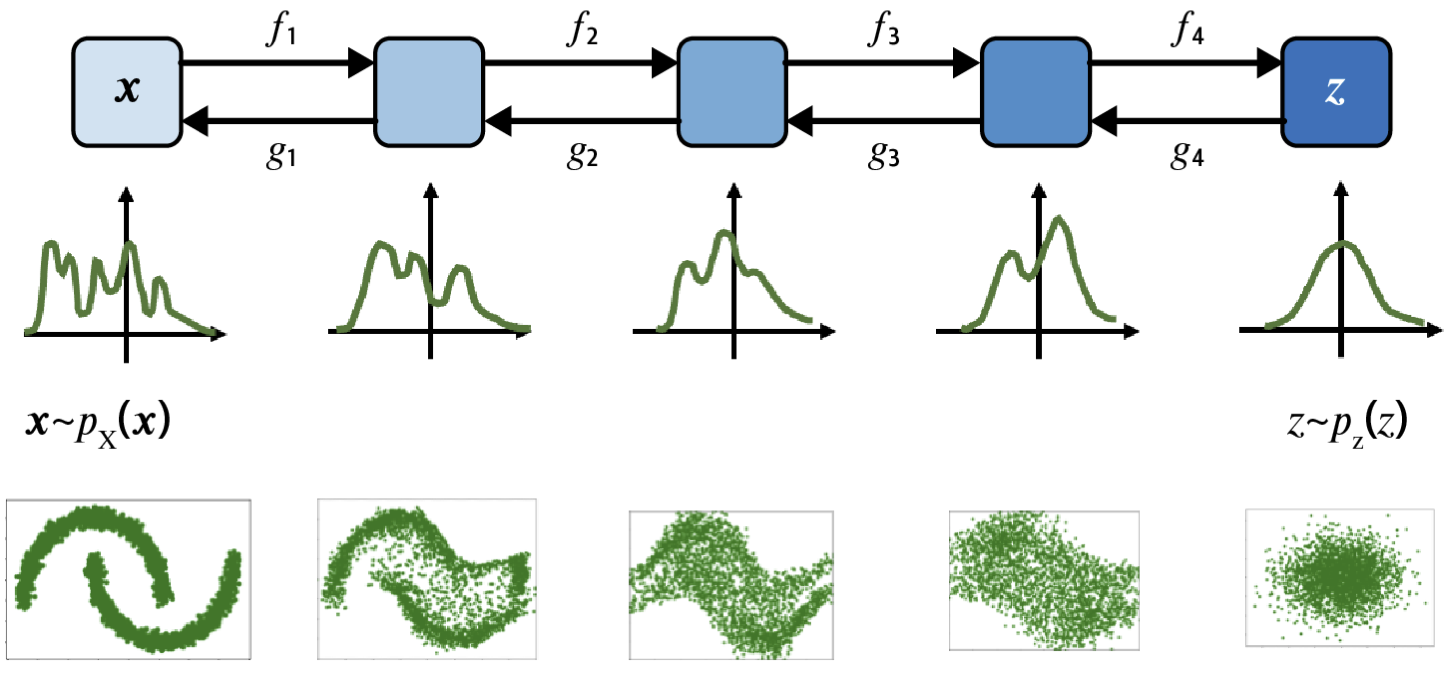

In [9]:
# Compile and train the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001))

In [10]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def generate(self):
        # From data to latent space.
        z, _ = model(normalized_data)

        # From latent space to data.
        samples = model.distribution.sample(self.num_samples)
        x, _ = model.predict(samples, verbose=0)

        return x, z, samples

    def display(self, x, z, samples, save_to=None):
        f, axes = plt.subplots(2, 2)
        f.set_size_inches(8, 5)

        axes[0, 0].scatter(
            normalized_data[:, 0], normalized_data[:, 1], color="r", s=1
        )
        axes[0, 0].set(title="Data space X", xlabel="x_1", ylabel="x_2")
        axes[0, 0].set_xlim([-2, 2])
        axes[0, 0].set_ylim([-2, 2])
        axes[0, 1].scatter(z[:, 0], z[:, 1], color="r", s=1)
        axes[0, 1].set(title="f(X)", xlabel="z_1", ylabel="z_2")
        axes[0, 1].set_xlim([-2, 2])
        axes[0, 1].set_ylim([-2, 2])
        axes[1, 0].scatter(samples[:, 0], samples[:, 1], color="g", s=1)
        axes[1, 0].set(title="Latent space Z", xlabel="z_1", ylabel="z_2")
        axes[1, 0].set_xlim([-2, 2])
        axes[1, 0].set_ylim([-2, 2])
        axes[1, 1].scatter(x[:, 0], x[:, 1], color="g", s=1)
        axes[1, 1].set(title="g(Z)", xlabel="x_1", ylabel="x_2")
        axes[1, 1].set_xlim([-2, 2])
        axes[1, 1].set_ylim([-2, 2])

        plt.subplots_adjust(wspace=0.3, hspace=0.6)
        if save_to:
            plt.savefig(save_to)
            print(f"\nSaved to {save_to}")

        plt.show()

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0:
            x, z, samples = self.generate()
            self.display(
                x,
                z,
                samples,
                save_to="./output/generated_img_%03d.png" % (epoch),
            )


img_generator_callback = ImageGenerator(num_samples=3000)

In [11]:
import os
# Create subdirectories
for path in ["./logs", "./output"]:
    try:
        os.mkdir(path)
        print("Directory '%s' created successfully" % path)
    except OSError as error:
        print("Directory '%s' exists" % path)

Directory './logs' exists
Directory './output' exists


Epoch 1/100
117/118 [============================>.] - ETA: 0s - loss: 2.4255
Saved to ./output/generated_img_000.png


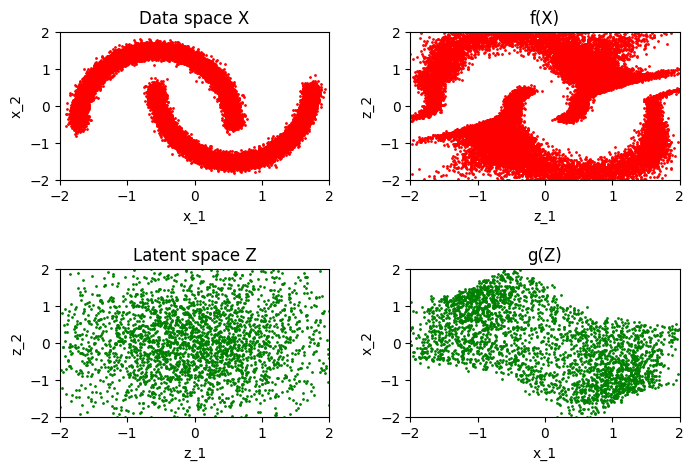

118/118 [==============================] - 5s 22ms/step - loss: 2.4234
Epoch 2/100
118/118 [==============================] - 3s 29ms/step - loss: 2.1451
Epoch 3/100
118/118 [==============================] - 3s 28ms/step - loss: 1.8879
Epoch 4/100
118/118 [==============================] - 3s 27ms/step - loss: 1.6068
Epoch 5/100
118/118 [==============================] - 3s 29ms/step - loss: 1.5237
Epoch 6/100
118/118 [==============================] - 4s 31ms/step - loss: 1.4629
Epoch 7/100
118/118 [==============================] - 4s 31ms/step - loss: 1.4030
Epoch 8/100
118/118 [==============================] - 4s 31ms/step - loss: 1.3308
Epoch 9/100
118/118 [==============================] - 4s 31ms/step - loss: 1.2951
Epoch 10/100
118/118 [==============================] - 4s 30ms/step - loss: 1.2839
Epoch 11/100
117/118 [============================>.] - ETA: 0s - loss: 1.2817
Saved to ./output/generated_img_010.png


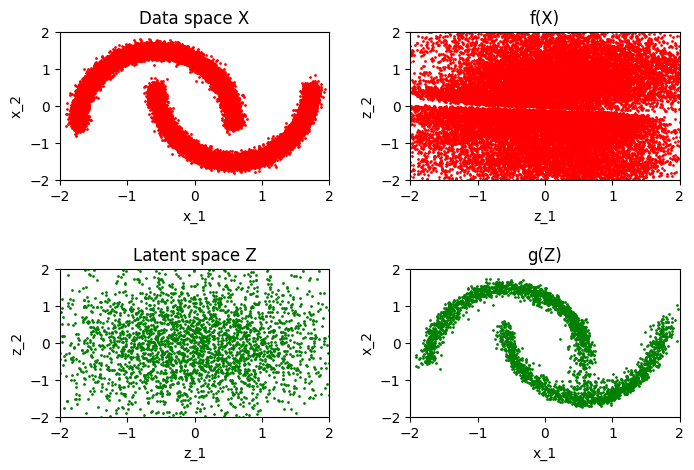

118/118 [==============================] - 4s 35ms/step - loss: 1.2804
Epoch 12/100
118/118 [==============================] - 4s 31ms/step - loss: 1.2693
Epoch 13/100
118/118 [==============================] - 3s 29ms/step - loss: 1.2614
Epoch 14/100
118/118 [==============================] - 4s 30ms/step - loss: 1.2616
Epoch 15/100
118/118 [==============================] - 4s 30ms/step - loss: 1.2583
Epoch 16/100
118/118 [==============================] - 3s 29ms/step - loss: 1.2529
Epoch 17/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2362
Epoch 18/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2394
Epoch 19/100
118/118 [==============================] - 3s 29ms/step - loss: 1.2489
Epoch 20/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2356
Epoch 21/100
117/118 [============================>.] - ETA: 0s - loss: 1.2330
Saved to ./output/generated_img_020.png


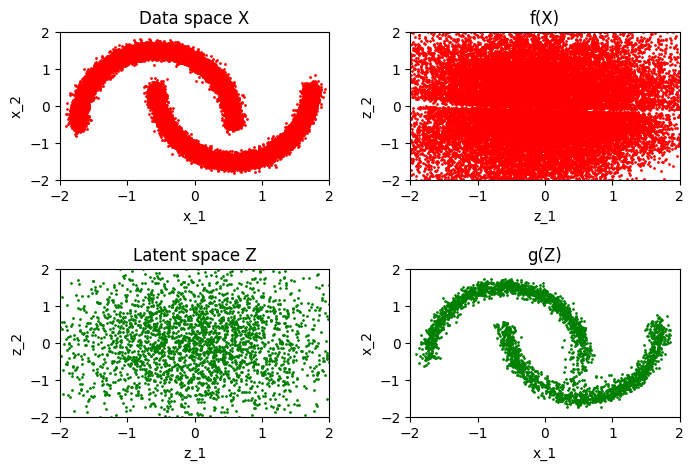

118/118 [==============================] - 4s 35ms/step - loss: 1.2325
Epoch 22/100
118/118 [==============================] - 3s 30ms/step - loss: 1.2273
Epoch 23/100
118/118 [==============================] - 3s 30ms/step - loss: 1.2320
Epoch 24/100
118/118 [==============================] - 3s 29ms/step - loss: 1.2245
Epoch 25/100
118/118 [==============================] - 3s 29ms/step - loss: 1.2323
Epoch 26/100
118/118 [==============================] - 4s 30ms/step - loss: 1.2338
Epoch 27/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2282
Epoch 28/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2224
Epoch 29/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2216
Epoch 30/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2317
Epoch 31/100
117/118 [============================>.] - ETA: 0s - loss: 1.2130
Saved to ./output/generated_img_030.png


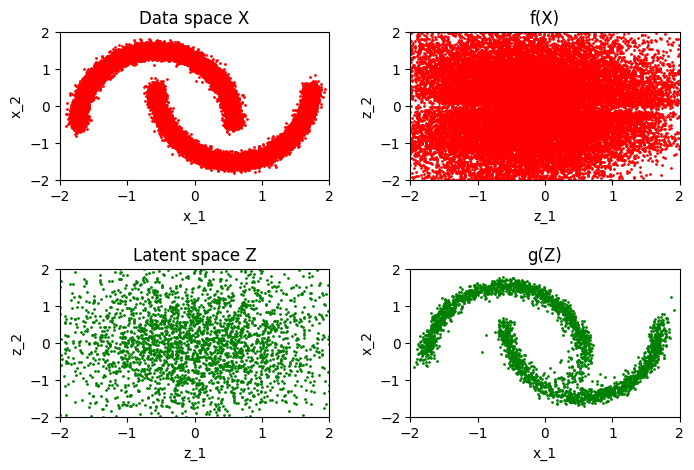

118/118 [==============================] - 4s 35ms/step - loss: 1.2153
Epoch 32/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2181
Epoch 33/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2227
Epoch 34/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2160
Epoch 35/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2089
Epoch 36/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2212
Epoch 37/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2111
Epoch 38/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2221
Epoch 39/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2116
Epoch 40/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2138
Epoch 41/100
117/118 [============================>.] - ETA: 0s - loss: 1.2101
Saved to ./output/generated_img_040.png


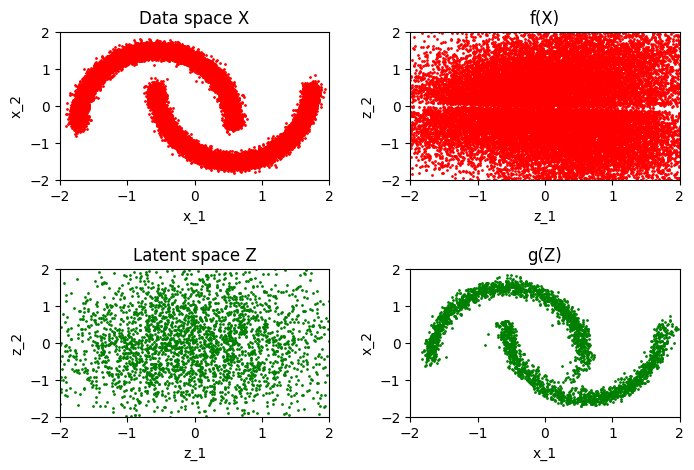

118/118 [==============================] - 4s 34ms/step - loss: 1.2105
Epoch 42/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2108
Epoch 43/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2081
Epoch 44/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2113
Epoch 45/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2108
Epoch 46/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2115
Epoch 47/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2165
Epoch 48/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2001
Epoch 49/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2070
Epoch 50/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2002
Epoch 51/100
117/118 [============================>.] - ETA: 0s - loss: 1.2034
Saved to ./output/generated_img_050.png


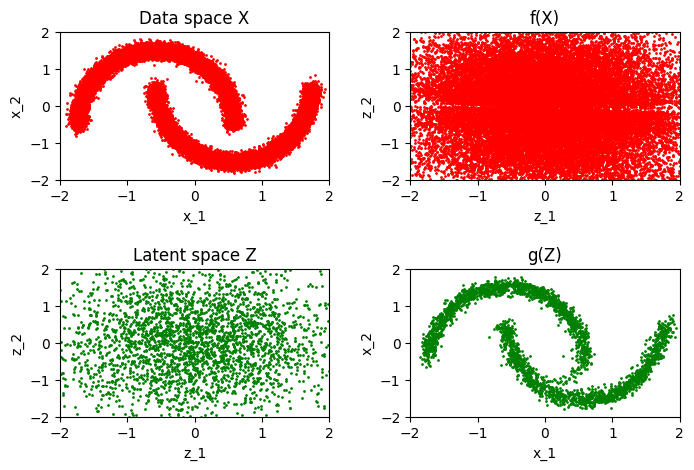

118/118 [==============================] - 4s 35ms/step - loss: 1.2049
Epoch 52/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2097
Epoch 53/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2026
Epoch 54/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2058
Epoch 55/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2039
Epoch 56/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2000
Epoch 57/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2003
Epoch 58/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2076
Epoch 59/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2039
Epoch 60/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2074
Epoch 61/100
117/118 [============================>.] - ETA: 0s - loss: 1.1999
Saved to ./output/generated_img_060.png


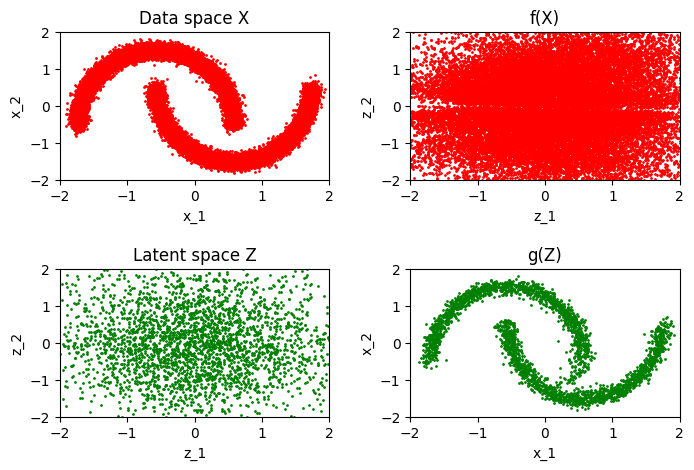

118/118 [==============================] - 4s 34ms/step - loss: 1.1997
Epoch 62/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1991
Epoch 63/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2022
Epoch 64/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2116
Epoch 65/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1968
Epoch 66/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1996
Epoch 67/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1963
Epoch 68/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2039
Epoch 69/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2048
Epoch 70/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1992
Epoch 71/100
117/118 [============================>.] - ETA: 0s - loss: 1.1971
Saved to ./output/generated_img_070.png


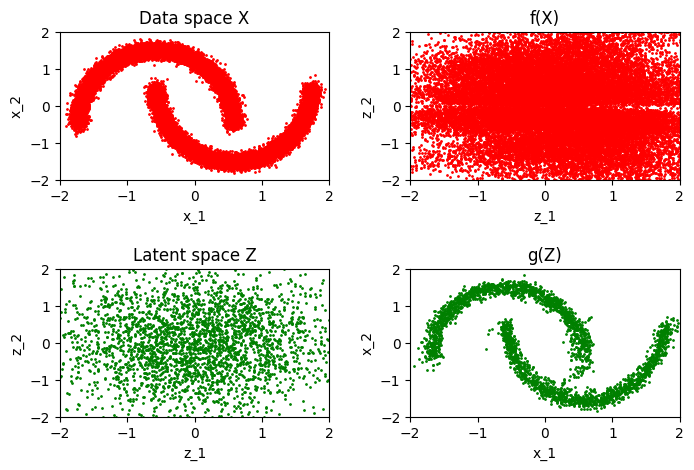

118/118 [==============================] - 4s 35ms/step - loss: 1.1960
Epoch 72/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1946
Epoch 73/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1962
Epoch 74/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2012
Epoch 75/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1911
Epoch 76/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2048
Epoch 77/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1994
Epoch 78/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2087
Epoch 79/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1948
Epoch 80/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1986
Epoch 81/100
117/118 [============================>.] - ETA: 0s - loss: 1.1870
Saved to ./output/generated_img_080.png


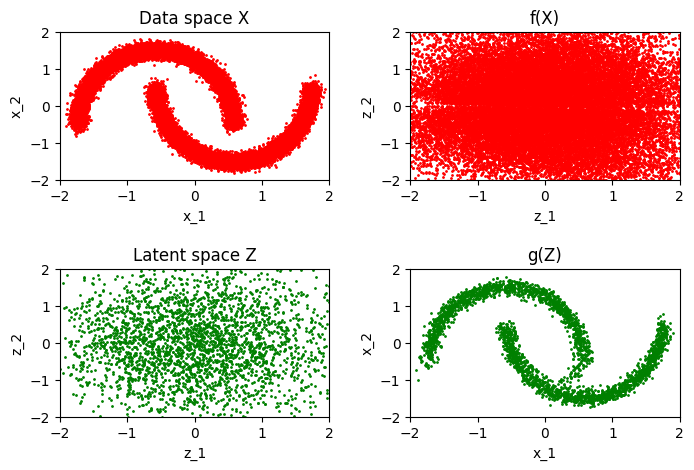

118/118 [==============================] - 4s 35ms/step - loss: 1.1858
Epoch 82/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1962
Epoch 83/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1893
Epoch 84/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1946
Epoch 85/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1990
Epoch 86/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1904
Epoch 87/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1892
Epoch 88/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1940
Epoch 89/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1932
Epoch 90/100
118/118 [==============================] - 3s 28ms/step - loss: 1.2005
Epoch 91/100
117/118 [============================>.] - ETA: 0s - loss: 1.1999
Saved to ./output/generated_img_090.png


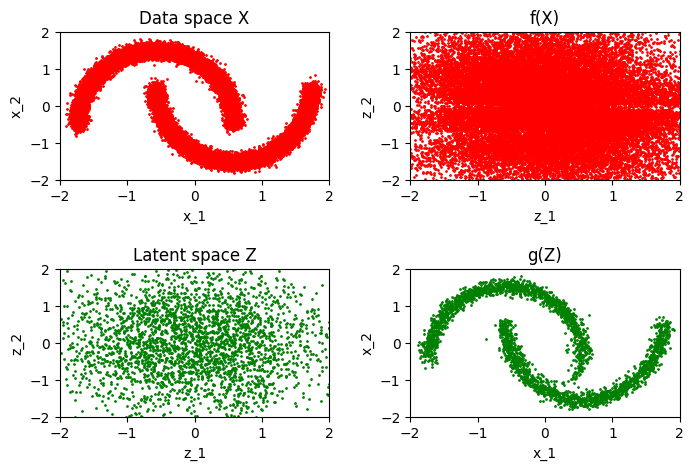

118/118 [==============================] - 4s 34ms/step - loss: 1.2001
Epoch 92/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1888
Epoch 93/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1913
Epoch 94/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1959
Epoch 95/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1873
Epoch 96/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1878
Epoch 97/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1964
Epoch 98/100
118/118 [==============================] - 3s 27ms/step - loss: 1.1896
Epoch 99/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1921
Epoch 100/100
118/118 [==============================] - 3s 28ms/step - loss: 1.1909


In [12]:
model.fit(
    normalized_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback, img_generator_callback],
)

## Анализ модели RealNVP

После обучения модели мы можем использовать ее для преобразования обучающего набора в скрытое пространство (используя прямое направление с функцией $f$) и, что более важно, для преобразования выбранной точки в скрытом пространстве в точку, которая выглядит так, как будто она могла бы быть были выбраны из исходного распределения данных (с использованием обратного направления с функцией $g$).

После обучения прямой процесс может преобразовать точки из обучающего набора в распределение, напоминающее гауссово. Аналогичным образом, обратный процесс может использовать точки, выбранные из распределения Гаусса, и отображать их обратно, получая распределение, которое напоминает исходные данные.

In [13]:
x, z, samples = img_generator_callback.generate()

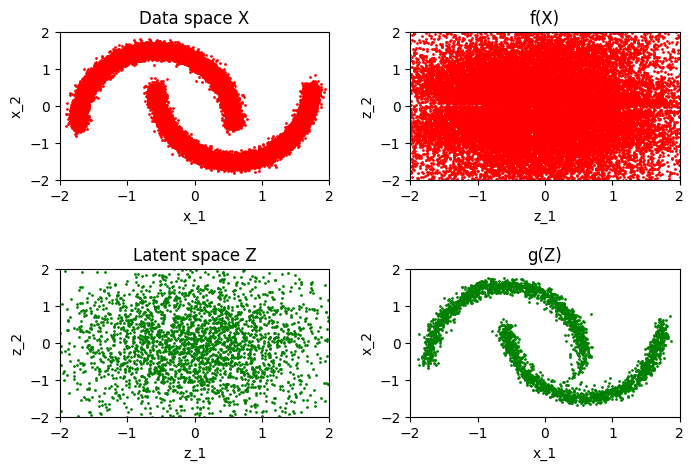

In [14]:
img_generator_callback.display(x, z, samples)